In [2]:
import os
import copy
import math
import subprocess
import sys

import numpy as np
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Auto-install missing lightweight deps in notebook environments.
try:
    import wfdb
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wfdb'])
    import wfdb

try:
    from tqdm.auto import tqdm
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tqdm'])
    from tqdm.auto import tqdm


/home/durgesh/.conda/envs/tf210/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def bandpass_filter(signal_data, fs=100, lowcut=0.5, highcut=40, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, signal_data)

def notch_filter(signal_data, fs=100, freq=50.0, Q=30.0):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = signal.iirnotch(w0, Q)
    return signal.filtfilt(b, a, signal_data)

def preprocess_signal(sig, fs=100):
    sig = np.asarray(sig, dtype=np.float32)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)

    sig = bandpass_filter(sig, fs)
    sig = notch_filter(sig, fs)

    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    std = np.std(sig)
    if std < 1e-8:
        return np.zeros_like(sig, dtype=np.float32)

    sig = (sig - np.mean(sig)) / (std + 1e-8)
    return sig.astype(np.float32)


In [4]:
def segment_signal(signal_data, annotations, fs=100):
    segments = []
    labels = []
    segment_length = fs * 60

    for i, label in enumerate(annotations):
        start = i * segment_length
        end = start + segment_length

        if end <= len(signal_data):
            seg = signal_data[start:end]
            if not np.isfinite(seg).all():
                continue
            segments.append(seg)
            labels.append(1 if label == 'A' else 0)

    return np.array(segments, dtype=np.float32), np.array(labels, dtype=np.int64)


In [5]:
def load_apnea_dataset(data_path):
    X_all = []
    y_all = []
    skipped = []

    # use records that have apnea annotations
    records = sorted(set(f.split('.')[0] for f in os.listdir(data_path) if f.endswith('.apn')))

    for rec in tqdm(records, desc='Loading records', unit='record'):
        try:
            record = wfdb.rdrecord(os.path.join(data_path, rec))
            annotation = wfdb.rdann(os.path.join(data_path, rec), 'apn')

            signal_data = record.p_signal[:, 0]
            signal_data = preprocess_signal(signal_data, fs=int(record.fs))

            segments, labels = segment_signal(signal_data, annotation.symbol, fs=int(record.fs))
            if len(segments) == 0:
                skipped.append((rec, 'no valid segments'))
                continue

            X_all.append(segments)
            y_all.append(labels)

        except Exception as e:
            skipped.append((rec, str(e)))

    if not X_all:
        raise ValueError('No valid records were loaded.')

    X_all = np.concatenate(X_all, axis=0).astype(np.float32)
    y_all = np.concatenate(y_all, axis=0).astype(np.int64)

    finite_ratio = float(np.isfinite(X_all).mean())
    class_counts = np.bincount(y_all, minlength=2)
    print(f"Total segments: {len(X_all)} | finite_ratio={finite_ratio:.6f}")
    print(f"Class counts -> Normal(0): {class_counts[0]}, Apnea(1): {class_counts[1]}")
    if skipped:
        print(f"Skipped records: {len(skipped)}")

    return X_all, y_all


In [6]:
data_path = "dataset/1.0.0"

X, y = load_apnea_dataset(data_path)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
train_counts = np.bincount(y_train, minlength=2)
test_counts = np.bincount(y_test, minlength=2)
print(f"Train class counts -> 0: {train_counts[0]}, 1: {train_counts[1]}")
print(f"Test class counts  -> 0: {test_counts[0]}, 1: {test_counts[1]}")


Loading records: 100%|██████████| 86/86 [00:11<00:00,  7.48record/s]


Total segments: 38222 | finite_ratio=1.000000
Class counts -> Normal(0): 23555, Apnea(1): 14667
Skipped records: 8
Train samples: 30577, Test samples: 7645
Train class counts -> 0: 18844, 1: 11733
Test class counts  -> 0: 4711, 1: 2934


In [7]:
class ApneaDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ApneaDataset(X_train, y_train), batch_size=64, num_workers=4, shuffle=True, pin_memory=True)
test_loader = DataLoader(ApneaDataset(X_test, y_test), batch_size=64, num_workers=4, pin_memory=True)


In [8]:
class PeriodicSparseAttentionFECG(nn.Module):
    """Periodicity-aware sparse attention with fixed local windows around periodic anchors."""
    def __init__(self,
                 fs: int,
                 d_model: int,
                 nhead: int,
                 bpm_min: int = 40,
                 bpm_max: int = 90,
                 bpm_step: int = 10,
                 attention_window_samples: int = 45,
                 k_top_peaks: int = 32,
                 attention_dropout: float = 0.1,
                 scale: float = None,
                 output_attention: bool = False):
        super().__init__()
        self.fs = fs
        self.d_model = d_model
        self.nhead = nhead
        self.d_head = d_model // nhead
        self.attention_window_samples = attention_window_samples
        self.k_top_peaks = k_top_peaks
        self.dropout = nn.Dropout(attention_dropout)
        self.scale = scale
        self.output_attention = output_attention
        self.scale = scale or (1.0 / math.sqrt(float(self.d_head)))
        self.factor = factor = 5 

        bpms = list(range(bpm_min, bpm_max + 1, bpm_step))
        self._periods_samples = [(60.0 * fs) / float(bpm) for bpm in bpms]

    def _get_periodic_indices(self, L_K, device):
        idx_set = []
        for p in self._periods_samples:
            p_int = max(1, int(round(p)))
            if p_int >= L_K:
                continue
            idx_set.extend(range(0, L_K, p_int))

        if not idx_set:
            step = max(1, L_K // 8)
            idx_set = list(range(0, L_K, step))

        idx = torch.tensor(sorted(set(idx_set)), dtype=torch.long, device=device)
        if idx.numel() > self.k_top_peaks:
            pick = torch.linspace(0, idx.numel() - 1, steps=self.k_top_peaks, device=device).long()
            idx = idx[pick]
        return idx
    
    def _get_initial_context(self, V, L_Q):
        B, H, _, D = V.shape
        v_mean = V.mean(dim=-2)
        return v_mean.unsqueeze(-2).expand(B, H, L_Q, D).clone()

    def _update_context(self, context, V, scores, selected_index):
        B, H, L_V, D = V.shape
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        context_selected = torch.matmul(attn, V)
        b_idx = torch.arange(B, device=context.device)[:, None, None]
        h_idx = torch.arange(H, device=context.device)[None, :, None]
        context[b_idx, h_idx, selected_index, :] = context_selected.type_as(context)
        return context, None  # Simplified, no attn_map


    # def forward(self, queries, keys, values):
    #     B, L_Q, H, D_head = queries.shape
    #     _, L_K, _, _ = keys.shape
    #     device = queries.device

    #     Q = queries.transpose(1, 2)
    #     K = keys.transpose(1, 2)
    #     V = values.transpose(1, 2)

    #     periodic_indices = self._get_periodic_indices(L_K, device)
        
    #     attn_mask = torch.full((L_Q, L_K), float('-inf'), device=device)
    #     for peak_idx in periodic_indices:
    #         start = max(0, peak_idx.item() - self.attention_window_samples)
    #         end = min(L_K, peak_idx.item() + self.attention_window_samples + 1)
    #         attn_mask[:, start:end] = 0.0
    #     attn_mask = attn_mask.unsqueeze(0).unsqueeze(0).expand(B, H, -1, -1)

    #     scale = self.scale or (1.0 / math.sqrt(D_head))
    #     scores = torch.matmul(Q, K.transpose(-2, -1)) * scale
    #     scores += attn_mask

    #     attn_weights = torch.softmax(scores, dim=-1)
    #     attn_weights = self.dropout(attn_weights)

    #     context = torch.matmul(attn_weights, V)
    #     context = context.transpose(1, 2).contiguous()

    #     attn_map = attn_weights if self.output_attention else None
    #     return context, attn_map
    
    def forward(self, queries, keys, values):
        B, L_Q, H, D_head = queries.shape
        _, L_K, _, _ = keys.shape
        device = queries.device
            
        Q = queries.transpose(1, 2)  # [B,H,LQ,D]
        K = keys.transpose(1, 2)     # [B,H,LK,D]
        V = values.transpose(1, 2)
            
            # COPY FROM FECG: Periodic + sparse extraction
        U_part = self.factor * math.ceil(math.log(max(1, L_K)))  # Add self.factor=5 to __init__
        periodic_idx_cpu = self._get_periodic_indices(L_K, device)
        sample_k = min(U_part, periodic_idx_cpu.numel())
        periodic_idx = periodic_idx_cpu[:sample_k].to(device)
            
        idx_expand = periodic_idx.view(1,1,1,sample_k).expand(B,H,L_Q,sample_k)
        K_sample = torch.gather(K.unsqueeze(2).expand(-1,-1,L_Q,-1,-1), 3, 
                                idx_expand.unsqueeze(-1).expand(-1,-1,-1,-1,D_head))
            
            # Sparse QK (O(n log n))
        S = torch.matmul(Q.unsqueeze(-2), K_sample.transpose(-2,-1)).squeeze(-2)
        M_metric = S.max(dim=-1)[0] - S.mean(dim=-1)
        u_eff = max(1, self.factor * math.ceil(math.log(max(1, L_Q))))
        _, topk_idx = M_metric.topk(u_eff, dim=-1, largest=True, sorted=False)
            
            # Final sparse refine
        b_idx = torch.arange(B, device=device)[:,None,None]
        h_idx = torch.arange(H, device=device)[None,:,None]
        Q_reduce = Q[b_idx, h_idx, topk_idx, :]
        scores_top = torch.matmul(Q_reduce, K.transpose(-2,-1)) * self.scale
            
            # COPY FROM FECG: Iterative context update (your _update_context)
        context = self._get_initial_context(V, L_Q)  # Add these two methods from FECG
        context, attn_map = self._update_context(context, V, scores_top, topk_idx)
            
        context = context.transpose(1, 2).contiguous()
        return context, attn_map



class SparseAttentionBlock(nn.Module):
    """Projection wrapper around PeriodicSparseAttentionFECG."""
    def __init__(self, in_channels, nhead, fs, bpm_range, dropout=0.1, attention_window_samples=45, k_top_peaks=32):
        super().__init__()
        if in_channels % nhead != 0:
            raise ValueError(f"in_channels ({in_channels}) must be divisible by nhead ({nhead}).")

        self.nhead = nhead
        self.d_model = in_channels
        self.d_head = self.d_model // nhead

        self.query_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)
        self.key_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)
        self.value_projection = nn.Conv1d(in_channels, self.d_model, kernel_size=1)

        self.attention = PeriodicSparseAttentionFECG(
            fs=fs,
            d_model=self.d_model,
            nhead=nhead,
            bpm_min=bpm_range[0],
            bpm_max=bpm_range[1],
            bpm_step=10,
            attention_window_samples=attention_window_samples,
            k_top_peaks=k_top_peaks,
            attention_dropout=dropout,
        )

        self.out_projection = nn.Conv1d(self.d_model, in_channels, kernel_size=1)

    def forward(self, x):
        B, C, T = x.shape
        H = self.nhead
        D_head = self.d_head

        q = self.query_projection(x).view(B, H, D_head, T).permute(0, 3, 1, 2)
        k = self.key_projection(x).view(B, H, D_head, T).permute(0, 3, 1, 2)
        v = self.value_projection(x).view(B, H, D_head, T).permute(0, 3, 1, 2)

        attn_output, _ = self.attention(q, k, v)
        attn_output = attn_output.permute(0, 2, 3, 1).reshape(B, C, T)
        return self.out_projection(attn_output)


class PCSA(nn.Module):
    def __init__(self, channels, fs=100, bpm_min=40, bpm_max=90, bpm_step=10, nhead=8, attention_window_samples=45, k_top_peaks=32):
        super().__init__()
        if channels % nhead != 0:
            raise ValueError(f"channels ({channels}) must be divisible by nhead ({nhead}).")
        self.block = SparseAttentionBlock(
            in_channels=channels,
            nhead=nhead,
            fs=fs,
            bpm_range=(bpm_min, bpm_max),
            dropout=0.1,
            attention_window_samples=attention_window_samples,
            k_top_peaks=k_top_peaks,
        )

    def forward(self, x):
        return self.block(x)



In [9]:
class Conv1DBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Conv2DBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TwoConvBranch2D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = Conv2DBlock(channels, channels)
        self.conv2 = Conv2DBlock(channels, channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x


class CustomApneaModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Multiscale transformation (Conv1d-BN-ReLU x3)
        self.ms1 = Conv1DBlock(1, 32, 3)
        self.ms2 = Conv1DBlock(1, 32, 5)
        self.ms3 = Conv1DBlock(1, 32, 7)

        # 2D feature extraction stem: Conv2d -> Pool -> Conv2d -> Pool
        self.stem_conv1 = Conv2DBlock(1, 32)
        self.pool1 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))
        self.stem_conv2 = Conv2DBlock(32, 64)
        self.pool2 = nn.MaxPool2d(kernel_size=(1, 2), stride=(1, 2))

        # Three parallel 2x Conv2d-BN-ReLU branches
        self.branch1 = TwoConvBranch2D(64)
        self.branch2 = TwoConvBranch2D(64)
        self.branch3 = TwoConvBranch2D(64)

        self.fuse = Conv2DBlock(64 * 3, 96)

        # Final PCSA block, then two linear layers
        self.pcsa = PCSA(96)
        self.fc1 = nn.Linear(96, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        # x: [B, 1, L]
        m1 = self.ms1(x)
        m2 = self.ms2(x)
        m3 = self.ms3(x)

        # Stack multiscale outputs as a 2D map: [B, 1, 3, T]
        ms = torch.stack([m1.mean(dim=1), m2.mean(dim=1), m3.mean(dim=1)], dim=1).unsqueeze(1)

        z = self.stem_conv1(ms)
        z = self.pool1(z)
        z = self.stem_conv2(z)
        z = self.pool2(z)

        b1 = self.branch1(z)
        b2 = self.branch2(z)
        b3 = self.branch3(z)

        z = torch.cat([b1, b2, b3], dim=1)
        z = self.fuse(z)

        # Convert 2D feature map to sequence and apply PCSA
        B, C, H, W = z.shape
        z = z.view(B, C, H * W)
        z = self.pcsa(z)

        z = z.mean(dim=-1)
        z = F.relu(self.fc1(z))
        z = self.fc2(z)

        return z


In [15]:
if torch.cuda.is_available():
    # Force single-GPU training on GPU 0
    torch.cuda.set_device(0)
    device = torch.device("cuda:3")
else:
    device = torch.device("cpu")

model = CustomApneaModel().to(device)

class_counts = np.bincount(y_train, minlength=2).astype(np.float32)
class_weights = class_counts.sum() / (2.0 * (class_counts + 1e-8))
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Device: {device}")
if device.type == "cuda":
    print(f"Using GPU: {torch.cuda.get_device_name(0)} | visible GPUs: {torch.cuda.device_count()}")
print(f"Class weights used in loss: {class_weights}")



Device: cuda:3
Using GPU: NVIDIA RTX A4000 | visible GPUs: 4
Class weights used in loss: [0.81131923 1.3030342 ]


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score

def train(model, loader, epoch_idx, num_epochs):
    model.train()
    total_loss = 0.0
    valid_batches = 0
    skipped_batches = 0

    pbar = tqdm(
        loader,
        total=len(loader),
        desc=f"Epoch {epoch_idx}/{num_epochs} Train",
        unit='batch',
        leave=True,
        dynamic_ncols=True,
        mininterval=0.2,
    )

    for X_batch, y_batch in pbar:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if not torch.isfinite(X_batch).all():
            skipped_batches += 1
            pbar.set_postfix(skipped=skipped_batches)
            continue

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        if not torch.isfinite(loss):
            skipped_batches += 1
            pbar.set_postfix(skipped=skipped_batches)
            continue

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        valid_batches += 1
        running_loss = total_loss / max(valid_batches, 1)
        pbar.set_postfix(loss=f"{running_loss:.4f}", valid=valid_batches, skipped=skipped_batches)

    mean_loss = total_loss / max(valid_batches, 1)
    return mean_loss, valid_batches, skipped_batches


def evaluate(model, loader, epoch_idx, num_epochs):
    model.eval()
    preds = []
    truths = []

    with torch.no_grad():
        pbar = tqdm(
            loader,
            total=len(loader),
            desc=f"Epoch {epoch_idx}/{num_epochs} Eval",
            unit='batch',
            leave=False,
            dynamic_ncols=True,
            mininterval=0.2,
        )
        for X_batch, y_batch in pbar:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            truths.extend(y_batch.numpy())

    preds = np.array(preds)
    truths = np.array(truths)

    tn, fp, fn, tp = confusion_matrix(truths, preds, labels=[0, 1]).ravel()

    accuracy = accuracy_score(truths, preds)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    pos_pred_rate = (preds == 1).mean()

    return accuracy, sensitivity, specificity, pos_pred_rate


In [17]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True 

In [18]:
num_epochs = 100
patience = 12
min_delta = 1e-4

best_acc = -1.0
best_epoch = 0
best_state = None
no_improve = 0

for epoch in range(1, num_epochs + 1):
    print()
    print(f"Starting epoch {epoch}/{num_epochs}")
    loss, valid_batches, skipped_batches = train(model, train_loader, epoch, num_epochs)
    acc, sen, spec, pos_rate = evaluate(model, test_loader, epoch, num_epochs)

    if acc > best_acc + min_delta:
        best_acc = acc
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1

    print(f"Epoch {epoch}/{num_epochs}")
    print(f"Loss: {loss:.4f} | valid_batches: {valid_batches} | skipped_batches: {skipped_batches}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Sensitivity: {sen:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"Positive prediction rate: {pos_rate:.4f}")
    print(f"Best Accuracy so far: {best_acc:.4f} (epoch {best_epoch})")
    print("-" * 40)

    if no_improve >= patience:
        print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs).")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best model from epoch {best_epoch} with accuracy {best_acc:.4f}.")



Starting epoch 1/100


Epoch 1/100 Train: 100%|██████████| 478/478 [01:31<00:00,  5.20batch/s, loss=0.5053, skipped=0, valid=478]


Epoch 1/100
Loss: 0.5053 | valid_batches: 478 | skipped_batches: 0
Accuracy: 0.4514
Sensitivity: 0.9915
Specificity: 0.1150
Positive prediction rate: 0.9258
Best Accuracy so far: 0.4514 (epoch 1)
----------------------------------------

Starting epoch 2/100


Epoch 2/100 Train: 100%|██████████| 478/478 [01:32<00:00,  5.14batch/s, loss=0.4027, skipped=0, valid=478]


Epoch 2/100
Loss: 0.4027 | valid_batches: 478 | skipped_batches: 0
Accuracy: 0.7863
Sensitivity: 0.9519
Specificity: 0.6831
Positive prediction rate: 0.5606
Best Accuracy so far: 0.7863 (epoch 2)
----------------------------------------

Starting epoch 3/100


...

Epoch 62/100
Loss: 0.1407 | valid_batches: 478 | skipped_batches: 0
Accuracy: 0.9264
Sensitivity: 0.9458
Specificity: 0.9142
Positive prediction rate: 0.4158
Best Accuracy so far: 0.9312 (epoch 52)
----------------------------------------

Starting epoch 63/100


Epoch 63/100 Train: 100%|██████████| 478/478 [01:30<00:00,  5.31batch/s, loss=0.1426, skipped=0, valid=478]


Epoch 63/100
Loss: 0.1426 | valid_batches: 478 | skipped_batches: 0
Accuracy: 0.9294
Sensitivity: 0.9196
Specificity: 0.9355
Positive prediction rate: 0.3927
Best Accuracy so far: 0.9312 (epoch 52)
----------------------------------------

Starting epoch 64/100


Epoch 64/100 Train: 100%|██████████| 478/478 [01:29<00:00,  5.31batch/s, loss=0.1419, skipped=0, valid=478]
                                                                       

Epoch 64/100
Loss: 0.1419 | valid_batches: 478 | skipped_batches: 0
Accuracy: 0.9266
Sensitivity: 0.9008
Specificity: 0.9427
Positive prediction rate: 0.3810
Best Accuracy so far: 0.9312 (epoch 52)
----------------------------------------
Early stopping at epoch 64 (no improvement for 12 epochs).
Loaded best model from epoch 52 with accuracy 0.9312.


In [19]:
# Final evaluation on the test set
# Use epoch labels for progress-bar compatible evaluate() signature.
final_acc, final_sen, final_spec, final_pos_rate = evaluate(model, test_loader, epoch_idx='Final', num_epochs='Final')

print("\nFinal Test Metrics")
print(f"Accuracy   : {final_acc:.4f}")
print(f"Sensitivity: {final_sen:.4f}")
print(f"Specificity: {final_spec:.4f}")
print(f"Pos. Rate  : {final_pos_rate:.4f}")



Final Test Metrics
Accuracy   : 0.9312
Sensitivity: 0.9335
Specificity: 0.9297
Pos. Rate  : 0.4016


In [20]:
# Export predictions to CSV for test_per_recording.py (no changes to previous cells)
import os
import pandas as pd

# Rebuild subject IDs per segment with the same record traversal used in load_apnea_dataset().
records = sorted(set(f.split('.')[0] for f in os.listdir(data_path) if f.endswith('.apn')))
subjects_all = []

for rec in tqdm(records, desc='Rebuilding subject ids', unit='record'):
    try:
        record = wfdb.rdrecord(os.path.join(data_path, rec))
        annotation = wfdb.rdann(os.path.join(data_path, rec), 'apn')

        signal_data = record.p_signal[:, 0]
        signal_data = preprocess_signal(signal_data, fs=int(record.fs))

        segments, labels = segment_signal(signal_data, annotation.symbol, fs=int(record.fs))
        if len(segments) == 0:
            continue

        subjects_all.extend([rec] * len(labels))
    except Exception:
        continue

subjects_all = np.array(subjects_all)

if len(subjects_all) != len(X):
    raise ValueError(f"Subject alignment mismatch: len(subjects_all)={len(subjects_all)} vs len(X)={len(X)}")

# Reproduce the exact split used earlier to align subject IDs with X_test / y_test.
_, _, _, _, _, subjects_test = train_test_split(
    X, y, subjects_all, test_size=0.2, stratify=y, random_state=42
)

# Inference: probability of apnea class (class 1)
model.eval()
y_true_list = []
y_score_list = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc='Export inference', unit='batch'):
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)[:, 1]

        y_true_list.extend(y_batch.cpu().numpy().astype(float).tolist())
        y_score_list.extend(probs.cpu().numpy().astype(float).tolist())

if len(y_true_list) != len(subjects_test):
    raise ValueError(f"Length mismatch: y_true={len(y_true_list)} vs subjects_test={len(subjects_test)}")

pred_df = pd.DataFrame({
    'y_true': y_true_list,
    'y_score': y_score_list,
    'subject': subjects_test.tolist(),
})

os.makedirs('output', exist_ok=True)
out_path = os.path.join('output', 'file_name.csv')
pred_df.to_csv(out_path, index=False)
print(f'Saved: {out_path} | rows={len(pred_df)}')
print(pred_df.head())


Rebuilding subject ids:   0%|          | 0/86 [00:00<?, ?record/s]

Export inference: 100%|██████████| 120/120 [00:09<00:00, 12.67batch/s]


Saved: output/file_name.csv | rows=7645
   y_true   y_score subject
0     0.0  0.009528     x03
1     0.0  0.000135     c01
2     0.0  0.503444     a06
3     0.0  0.000078     x34
4     0.0  0.003368     c07


Confusion Matrix (rows=true, cols=pred)
[[4380  331]
 [ 195 2739]]


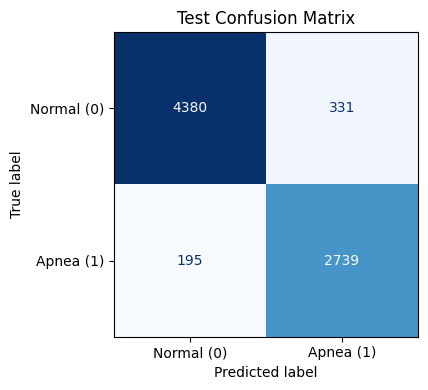

In [21]:
# Confusion matrix on test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
y_true_cm = []
y_pred_cm = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_true_cm.extend(y_batch.cpu().numpy())
        y_pred_cm.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true_cm, y_pred_cm, labels=[0, 1])
print('Confusion Matrix (rows=true, cols=pred)')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Apnea (1)'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Test Confusion Matrix')
plt.tight_layout()
plt.show()
